In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#OUTLIERS

#Outliers have to be interpreted according to the use case...
#We can already imagine how outlier can affect the slope of the BFL during a ML model training...
#The main thing is that, we should understand when to remove them and when to use them...

#Lets say we have a dataset representing MARKS vs STUDY_HRS....Now when we see few students getting high marks even after studying for less hrs...
#We know that that would afffect the BFL...

#On the other hand, let us consider a dataset to predict potential fraud in a transaction in a bank dataset...
#In this scenerio, the outliers are the ones we are looking for to find the suspiscious transactions...

#This is really important to understand before handling the outliers in EDA process...

#ML models like Linear and Logistic Regressions and major algos in DL are impacted a lot due to unnecessary outliers present in the dataset...
#The weights used in these models are impacted due to outliers and this leads to ambuguity in predictions...

In [4]:
#How to treat OUTLIERS

#Trimming - #This leads to data thinning, as we remove the outliers directly...
            #This is a faster approach than any other as this does not need any extra processing except for some mathematical functions....
#Capping - #Outliers are either too greter than the limit...or vice versa...
           #So in capping, we do not remove the datapoints...rather we replace the outlier values with the outlier range limit value simply...
           #Thus, there is no such outlier present then....
           #This process is called CAPPING...
#Missing Assumption - #Consider outlier values as missing NAN values...Thereby we can use IMPUTER techniques to fill data in them...

#Trimming and Capping are the most efficient for most of the times...and yet are most commonly used...

In [5]:
#Now the mathematics part...

#We considert the Normal Distribution for figuring this out...
#In between 1Sigma observatins...there lier...68.2% observations...
            #2Sigma - 95.4%
            #3Sigma - 99.7%

#Thus, when we see values exceeding these observations, we say that they are outliers...
#The formulae used is....(Mean +_ 3 Sigma) 

#The 3 denotes 3rd range of Sigma .... +_ represents outlier detection at both ends of the value graph...
#So any values exceeding this equation are considered outlier and are treated accordingly...

#So in case where there is a handful of outliers, we use Trimming...and in case where there is a greater number...we test Capping and observe first whether
#The final values are suitable....

#There are often times when Capping or Trimming a large number may lead to incorrect predictions...

In [6]:
#Now lets come to the part of Skewed Distribution of data...
#We use the concepts of IQR ( Inter - Quartile Range) in case of skewed distributions...

#The range values...

#Minimum - Q1 - 1.5*IQR
#Maximum  - Q3 + 1.5*IQR

#Where IQR = Q3 - Q1
#Q1 - 25 %ile
#Q3 - 75 %ile

In [7]:
#This is used for majorly other distributions...
#Values above Q3 and below Q1 are removed...

#This is the percentile method....

In [8]:
#Before touching data considering it an outlier....Always question first...whether the data that seems to be outlier is actually
#one...or is it worth understanding...

In [24]:
df = pd.read_csv('train.csv')
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [26]:
df.shape

(1309, 28)

<Axes: ylabel='Age'>

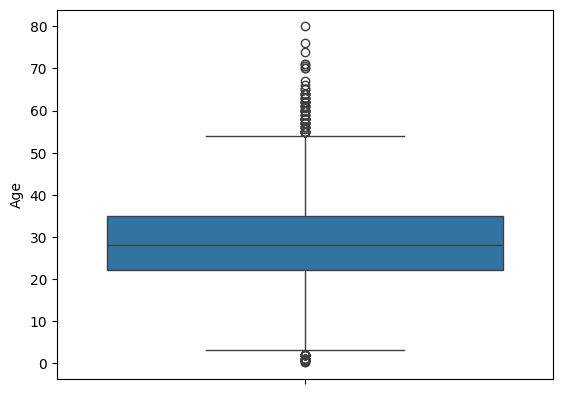

In [27]:
sns.boxplot(df['Age'])

In [28]:
meann = df['Age'].mean()
stdn = df['Age'].std()
print("Mean : ",meann)
print("STD : ",stdn)

Mean :  29.50318563789152
STD :  12.905240585464622


In [29]:
df = df[(df['Age']>= meann-(3*stdn)) & (df['Age']<= meann+(3*stdn))]
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [30]:
df.shape

(1301, 28)

<Axes: ylabel='Age'>

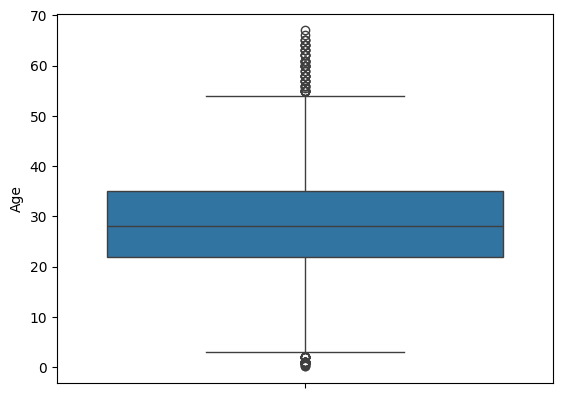

In [31]:
sns.boxplot(df['Age'])

In [ ]:
# ============================================
# OUTLIER DETECTION
# ============================================

# Outliers must be interpreted per use case:
# - Marks vs Study_hrs: high-marks/low-study outlier hurts the regression line -> handle it
# - Fraud detection: the outlier IS the target signal -> do NOT remove it
# Outliers affect model weights (esp. Linear/Logistic Regression, DL) -> ambiguous predictions

# TREATMENT METHODS
# Trimming - removes outlier rows entirely. Fast, but PERMANENTLY loses that data 
#            (risk: deletes real signal, e.g. genuinely gifted students)
# Capping  - replaces outlier value with the boundary limit value. Keeps the row 
#            but still distorts the true magnitude of that point
# Missing Assumption - treat outlier as NaN, then apply imputation techniques

# Z-SCORE / 3-SIGMA METHOD (for roughly symmetric/normal distributions)
# Empirical rule: 1σ ≈ 68.2%, 2σ ≈ 95.4%, 3σ ≈ 99.7% of data
# Bounds: Mean ± 3*Std
# Looser threshold - only flags the most extreme ~0.3% of values

# IQR METHOD (for skewed distributions - rank-based, not mean/std based)
# Q1 = 25th percentile, Q3 = 75th percentile, IQR = Q3 - Q1
# Bounds: [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
# Stricter than Z-score on skewed data - flags more points as outliers
# This is also the exact rule seaborn boxplots use to draw whiskers/dots -
# so a boxplot can still show dots even after Z-score cleaning, since the 
# two methods define "outlier" differently

# KEY JUDGMENT CALL (not just math):
# Detection (Z-score/IQR) tells you WHERE the boundary is.
# It does NOT tell you whether a flagged point is a real error or valid rare data.
# IQR removal narrows your dataset to the dominant cluster only - use it when 
# that narrower focus is actually your goal, not by default.
# Example: removing all elderly/young Titanic passengers via IQR would leave 
# a model that only understands middle-aged passengers - a real loss of generalization.